"" - 
Index counter
	
"carat" - 
Carat weight of the diamond
	
"cut" - 
Describe cut quality of the diamond. Quality in increasing order Fair, Good, Very Good, Premium, Ideal
	
"color" -
Color of the diamond, with D being the best and J the worst
	
"clarity" -
How obvious inclusions are within the diamond:(in order from best to worst, FL = flawless, I3= level 3 inclusions) FL,IF, VVS1, VVS2, VS1, VS2, SI1, SI2, I1, I2, I3
	
"depth" -
depth % :The height of a diamond, measured from the culet to the table, divided by its average girdle diameter
total depth percentage = z / mean(x, y) = 2 * z / (x + y)
	
"table" -
table%: The width of the diamond's table expressed as a percentage of its average diameter
	
"price" - 
the price of the diamond
	
"x" - 
length mm
	
"y" - 
width mm

z
depth in mm (0--31.8)

## 📋 Project Checklist: Diamond Price Regression

### 1. Data Loading & Initial Inspection
- [x] Import required libraries (pandas, numpy, matplotlib, seaborn, sklearn)
- [x] Load the diamonds.csv dataset
- [x] Drop the unnamed index column
- [x] Display dataset shape, data types, and first rows
- [x] Check for missing values
- [x] Generate descriptive statistics (.describe())

### 2. Exploratory Data Analysis (EDA)
- [x] **Target Variable Analysis**
  - [x] Plot histogram of price distribution
  - [x] Plot boxplot of price to identify outliers
- [x] **Numerical Features Analysis**
  - [x] Plot histograms for all numeric columns (carat, depth, table, x, y, z)
  - [x] Create scatter plots: price vs carat, price vs x, price vs y, price vs z
- [x] **Categorical Features Analysis**
  - [x] Plot boxplots: price by cut, price by color, price by clarity
  - [x] Show value counts for each categorical variable
- [x] **Correlation Analysis**
  - [x] Compute correlation matrix for numeric features
  - [x] Display correlation heatmap
  - [x] Identify highly correlated features

### 3. Data Preprocessing
- [x] **Handle Anomalies/Outliers**
  - [x] Identify rows where x, y, or z = 0 (invalid dimensions)
  - [x] Remove or handle anomalous records
- [x] **Encode Categorical Variables**
  - [x] Define ordinal rankings for cut (Fair < Good < Very Good < Premium < Ideal)
  - [x] Define ordinal rankings for color (J < I < H < G < F < E < D)
  - [x] Define ordinal rankings for clarity (I1 < SI2 < SI1 < VS2 < VS1 < VVS2 < VVS1 < IF)
  - [x] Apply OrdinalEncoder to categorical columns
- [x] **Feature Engineering (Optional)**
  - [x] Create volume feature (x * y * z)
- [x] **Split Data**
  - [x] Split into training (80%) and testing (20%) sets
  - [x] Set random_state for reproducibility
- [x] **Feature Scaling**
  - [x] Apply StandardScaler to features (for regularized models)

### 4. Model Training
- [x] **Linear Regression**
  - [x] Train Linear Regression model
  - [x] Extract coefficients and intercept
- [x] **Polynomial Regression**
  - [x] Create polynomial features (degree 2)
  - [x] Train Linear Regression on polynomial features
  - [x] Extract polynomial coefficients
- [x] **Ridge Regression (L2 Regularization)**
  - [x] Train Ridge model with appropriate alpha
  - [x] Extract coefficients
- [x] **Lasso Regression (L1 Regularization)**
  - [x] Train Lasso model with appropriate alpha
  - [x] Extract coefficients

### 5. Model Evaluation
- [x] **Compute Metrics for Each Model**
  - [x] R² Score (coefficient of determination)
  - [x] RMSE (Root Mean Squared Error)
  - [x] MAE (Mean Absolute Error)
- [x] **Visualize Model Performance**
  - [x] Plot Actual vs Predicted values for each model
  - [x] Plot residuals distribution
- [x] **Create Comparison Table**
  - [x] Summarize all models with their metrics side-by-side

### 6. Final Model Presentation
- [x] Select best performing model based on metrics
- [x] Display full equation with coefficients
- [x] Print coefficient table with feature names
- [x] Summarize key findings and model limitations

---
## 1. Data Loading & Initial Inspection

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)

# Load dataset
dataset_path = "./Datasets/diamonds.csv"
df = pd.read_csv(dataset_path)

# Drop unnamed index column
df = df.drop(columns=['Unnamed: 0'], errors='ignore')

# Rename for clarity
df.rename(columns={'depth':'depth_%', 'x': 'length', 'y': 'width', 'z': 'depth'}, inplace=True)

# print(f"✅ Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print(f"Data Types:")
print(df.dtypes)
print(f"First 5 rows:")
df.head()

Shape: (53940, 10)
Data Types:
carat      float64
cut         object
color       object
clarity     object
depth_%    float64
table      float64
price        int64
length     float64
width      float64
depth      float64
dtype: object
First 5 rows:


,carat,cut,color,clarity,depth_%,table,price,length,width,depth
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [2]:
# Check for missing values and descriptive statistics
print("Missing Values:")
print(df.isnull().sum())
print(f"Descriptive Statistics:")
df.describe()

Missing Values:
carat      0
cut        0
color      0
clarity    0
depth_%    0
table      0
price      0
length     0
width      0
depth      0
dtype: int64
Descriptive Statistics:


,carat,depth_%,table,price,length,width,depth
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


---
## 2. Exploratory Data Analysis (EDA)

### 2.1 Target Variable Analysis (Price)

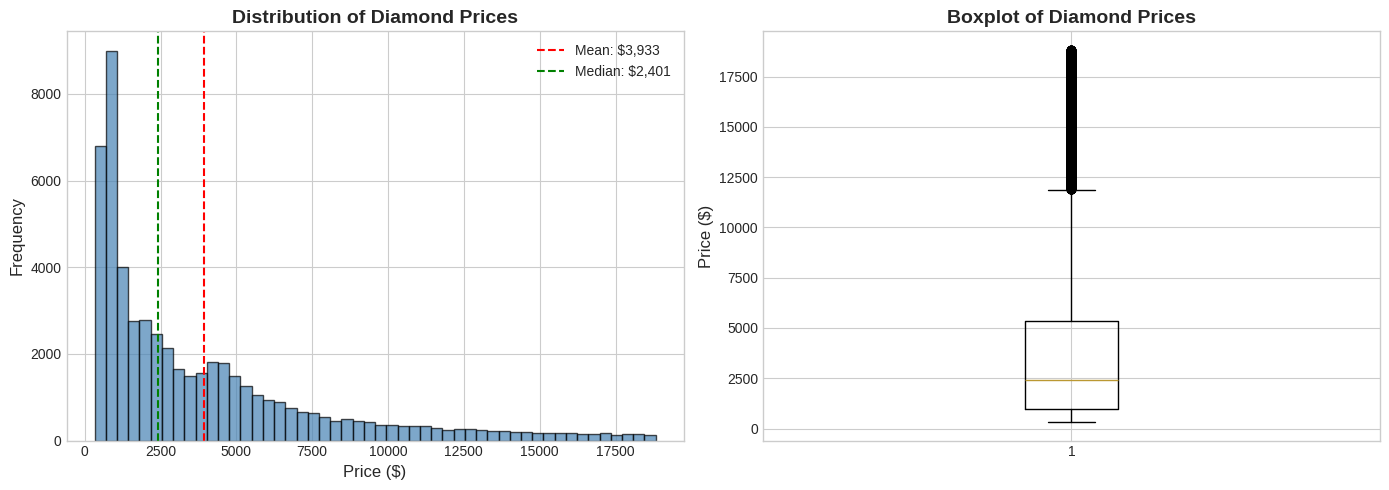

Price Statistics:
Min: $326
Max: $18,823
Mean: $3,932.80
Median: $2,401.0
Std Dev: $3,989.44


In [3]:
# Target Variable Analysis - Price Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of price
axes[0].hist(df['price'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_xlabel('Price ($)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Distribution of Diamond Prices', fontsize=14, fontweight='bold')
axes[0].axvline(df['price'].mean(), color='red', linestyle='--', label=f"Mean: ${df['price'].mean():,.0f}")
axes[0].axvline(df['price'].median(), color='green', linestyle='--', label=f"Median: ${df['price'].median():,.0f}")
axes[0].legend()

# Boxplot of price
axes[1].boxplot(df['price'], vert=True)
axes[1].set_ylabel('Price ($)', fontsize=12)
axes[1].set_title('Boxplot of Diamond Prices', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Price Statistics:")
print(f"Min: ${df['price'].min():,}")
print(f"Max: ${df['price'].max():,}")
print(f"Mean: ${df['price'].mean():,.2f}")
print(f"Median: ${df['price'].median():,}")
print(f"Std Dev: ${df['price'].std():,.2f}")

### 2.2 Numerical Features Analysis

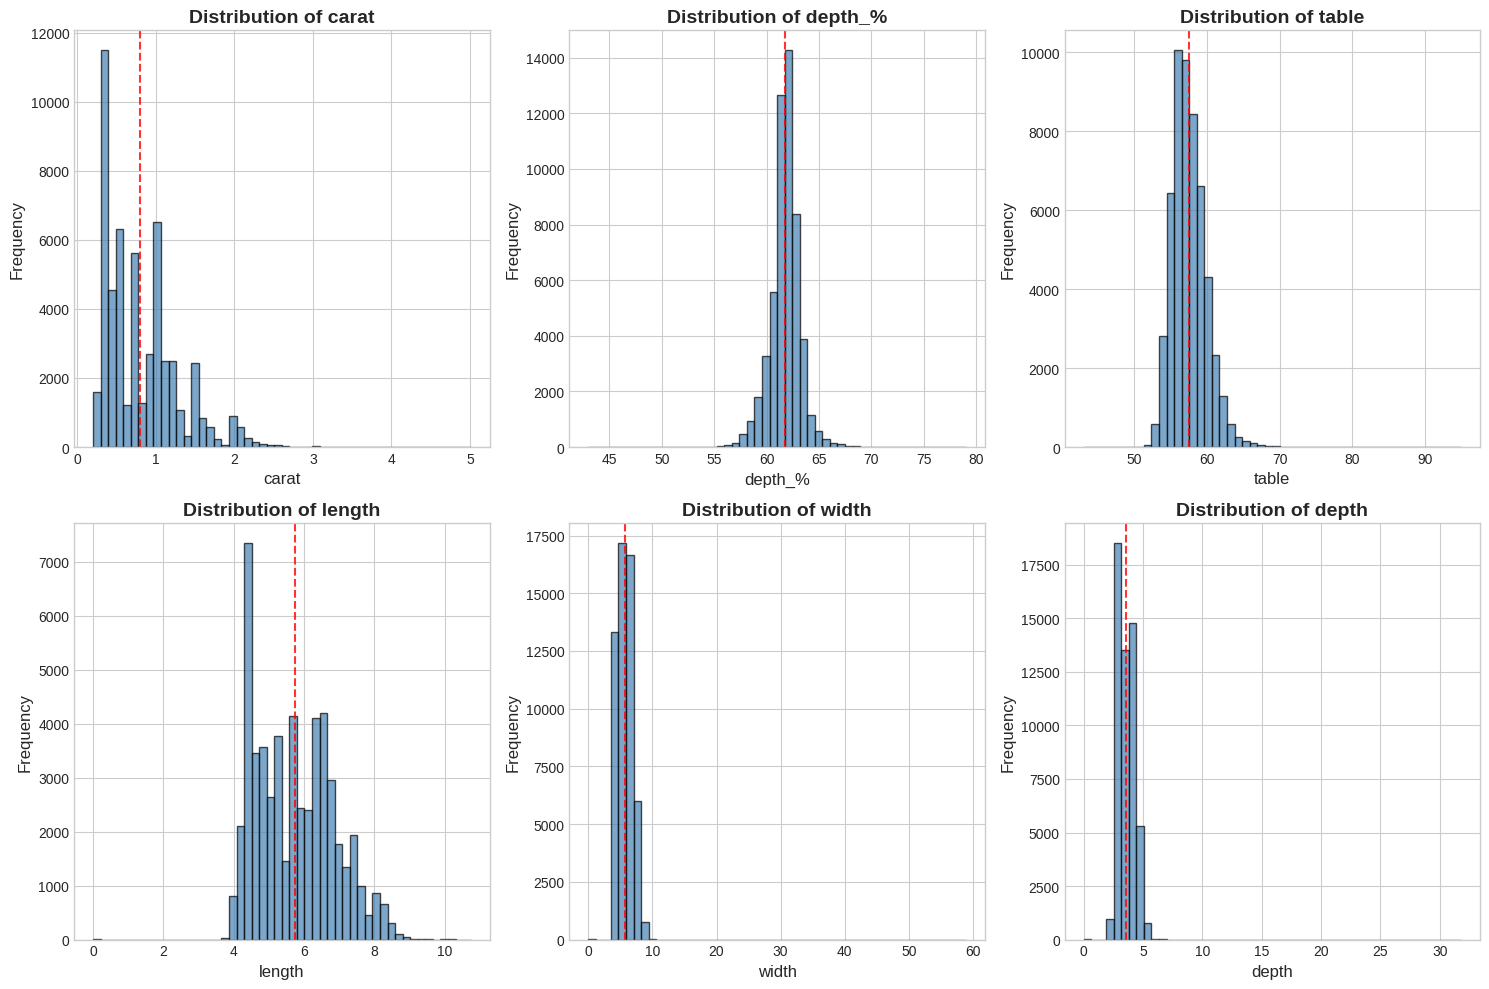

In [4]:
# Histograms for numerical features
numeric_cols = ['carat', 'depth_%', 'table', 'length', 'width', 'depth']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
    axes[i].set_xlabel(col, fontsize=12)
    axes[i].set_ylabel('Frequency', fontsize=12)
    axes[i].set_title(f'Distribution of {col}', fontsize=14, fontweight='bold')
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', alpha=0.8)

plt.tight_layout()
plt.show()

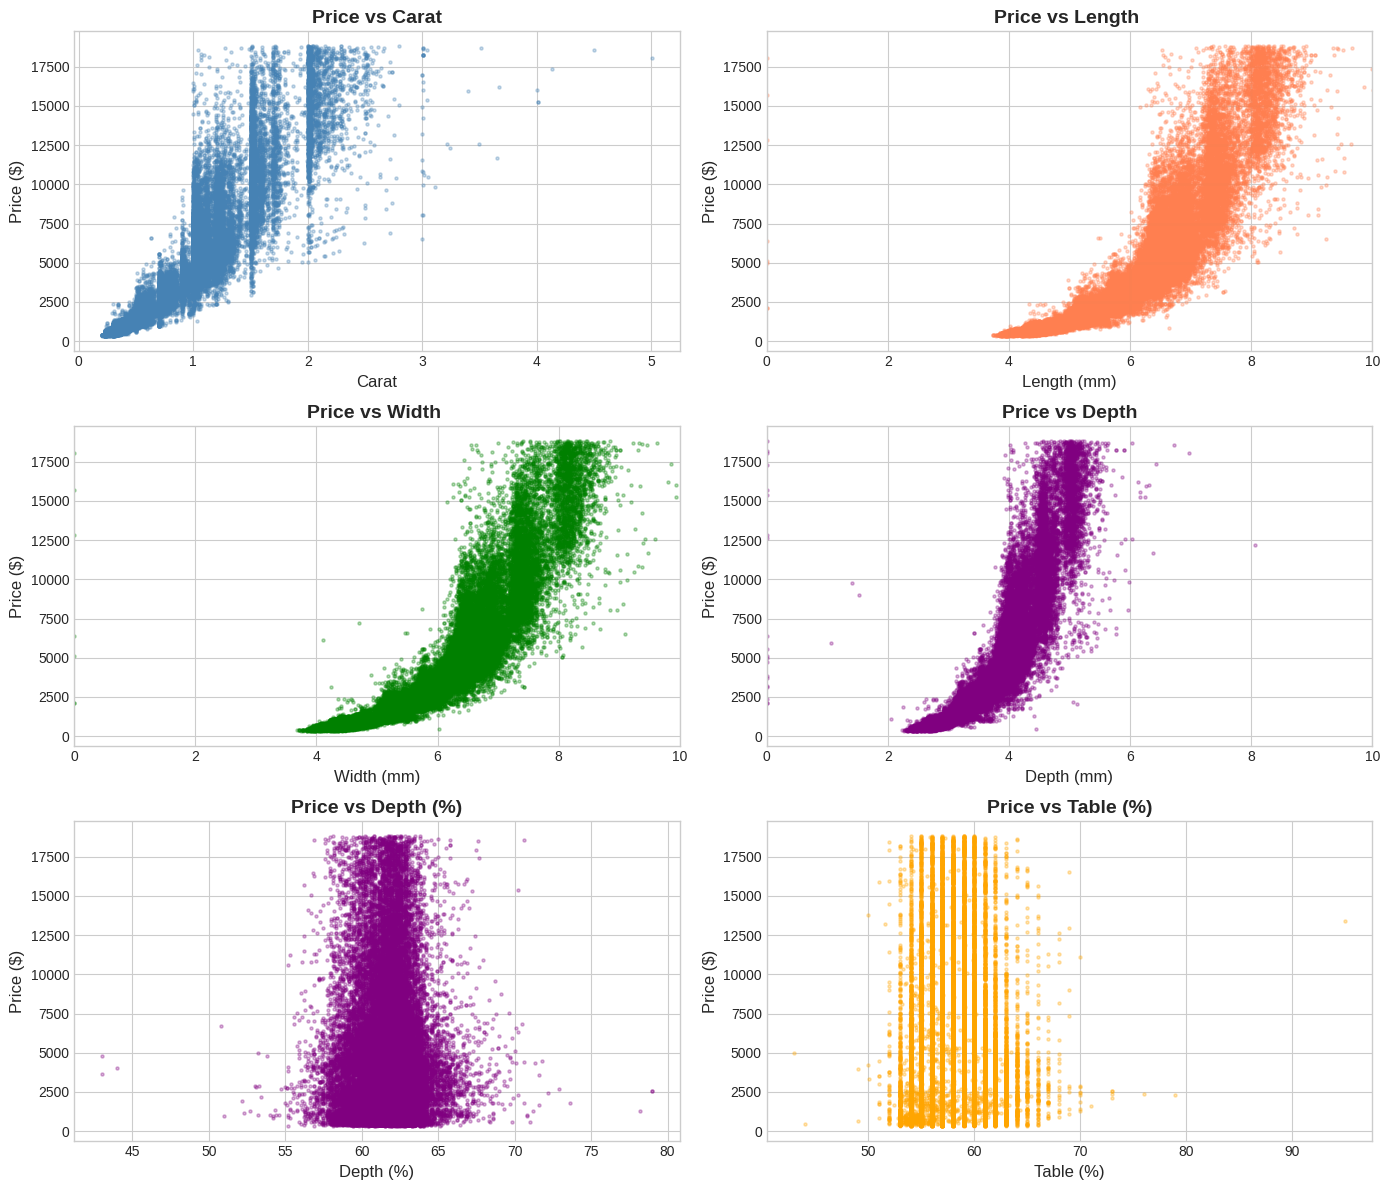

In [5]:
# Scatter plots: Price vs key numerical features
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

# Price vs Carat
axes[0, 0].scatter(df['carat'], df['price'], alpha=0.3, s=5, c='steelblue')
axes[0, 0].set_xlabel('Carat', fontsize=12)
axes[0, 0].set_ylabel('Price ($)', fontsize=12)
axes[0, 0].set_title('Price vs Carat', fontsize=14, fontweight='bold')

# Price vs x (length)
axes[0, 1].scatter(df['length'], df['price'], alpha=0.3, s=5, c='coral')
axes[0, 1].set_xlabel('Length (mm)', fontsize=12)
axes[0, 1].set_ylabel('Price ($)', fontsize=12)
axes[0, 1].set_title('Price vs Length ', fontsize=14, fontweight='bold')
axes[0, 1].set_xbound(0, 10)  

# Price vs y (width)
axes[1, 0].scatter(df['width'], df['price'], alpha=0.3, s=5, c='green')
axes[1, 0].set_xlabel('Width (mm)', fontsize=12)
axes[1, 0].set_ylabel('Price ($)', fontsize=12)
axes[1, 0].set_title('Price vs Width ', fontsize=14, fontweight='bold')
axes[1, 0].set_xbound(0, 10)

# Price vs z (depth)
axes[1, 1].scatter(df['depth'], df['price'], alpha=0.3, s=5, c='purple')
axes[1, 1].set_xlabel('Depth (mm)', fontsize=12)
axes[1, 1].set_ylabel('Price ($)', fontsize=12)
axes[1, 1].set_title('Price vs Depth', fontsize=14, fontweight='bold')
axes[1, 1].set_xbound(0, 10)

# price vs depth percentage
axes[2, 0].scatter(df['depth_%'], df['price'], alpha=0.3, s=5, c='purple')
axes[2, 0].set_xlabel('Depth (%)', fontsize=12)
axes[2, 0].set_ylabel('Price ($)', fontsize=12)     
axes[2, 0].set_title('Price vs Depth (%)', fontsize=14, fontweight='bold')

# price vs table
axes[2, 1].scatter(df['table'], df['price'], alpha=0.3, s=5, c='orange')
axes[2, 1].set_xlabel('Table (%)', fontsize=12)
axes[2, 1].set_ylabel('Price ($)', fontsize=12)
axes[2, 1].set_title('Price vs Table (%)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# print("📝 Key Observation: Price shows a strong non-linear relationship with carat and dimensions.")

### 2.3 Categorical Features Analysis

In [6]:
# Value counts for categorical variables
categorical_cols = ['cut', 'color', 'clarity']

print("📊 Categorical Variable Distributions:\n")
for col in categorical_cols:
    print(f"--- {col.upper()} ---")
    print(df[col].value_counts())
    print()

📊 Categorical Variable Distributions:

--- CUT ---
cut
Ideal        21551
Premium      13791
Very Good    12082
Good          4906
Fair          1610
Name: count, dtype: int64

--- COLOR ---
color
G    11292
E     9797
F     9542
H     8304
D     6775
I     5422
J     2808
Name: count, dtype: int64

--- CLARITY ---
clarity
SI1     13065
VS2     12258
SI2      9194
VS1      8171
VVS2     5066
VVS1     3655
IF       1790
I1        741
Name: count, dtype: int64



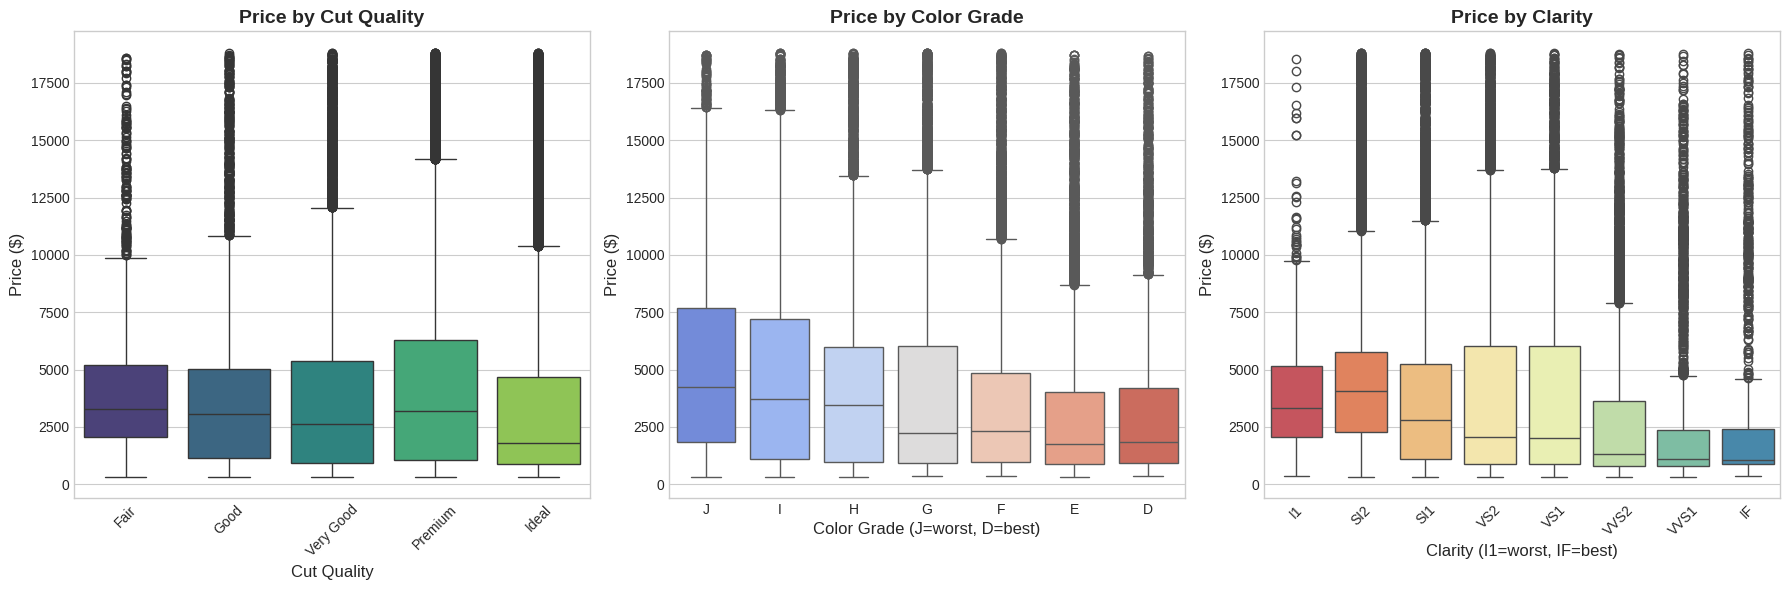

In [7]:
# Boxplots: Price by categorical features
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Define ordinal order for each categorical variable
cut_order = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
color_order = ['J', 'I', 'H', 'G', 'F', 'E', 'D']  # Worst to best
clarity_order = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']  # Worst to best

# Price by Cut
sns.boxplot(x='cut', y='price', data=df, order=cut_order, ax=axes[0], palette='viridis')
axes[0].set_xlabel('Cut Quality', fontsize=12)
axes[0].set_ylabel('Price ($)', fontsize=12)
axes[0].set_title('Price by Cut Quality', fontsize=14, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

# Price by Color
sns.boxplot(x='color', y='price', data=df, order=color_order, ax=axes[1], palette='coolwarm')
axes[1].set_xlabel('Color Grade (J=worst, D=best)', fontsize=12)
axes[1].set_ylabel('Price ($)', fontsize=12)
axes[1].set_title('Price by Color Grade', fontsize=14, fontweight='bold')

# Price by Clarity
sns.boxplot(x='clarity', y='price', data=df, order=clarity_order, ax=axes[2], palette='Spectral')
axes[2].set_xlabel('Clarity (I1=worst, IF=best)', fontsize=12)
axes[2].set_ylabel('Price ($)', fontsize=12)
axes[2].set_title('Price by Clarity', fontsize=14, fontweight='bold')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### 2.4 Correlation Analysis

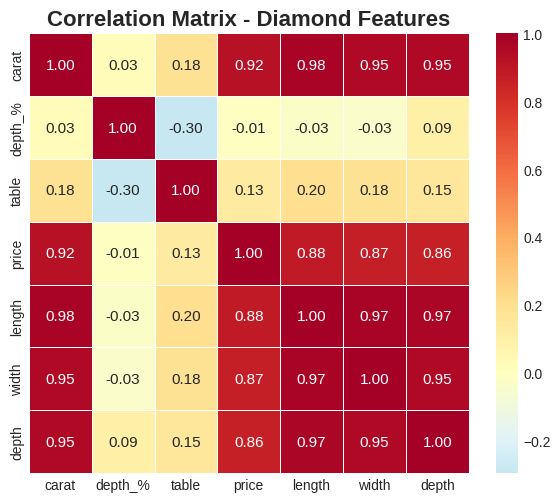

Correlation with Price:
   carat: 0.9216
   length: 0.8844
   width: 0.8654
   depth: 0.8612
   table: 0.1271
   depth_%: -0.0106


In [8]:
# Correlation Matrix and Heatmap
numeric_df = df.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr()

plt.figure(figsize=(6, 5))
# mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, annot=True, cmap='RdYlBu_r', center=0, 
            fmt='.2f', square=True, linewidths=0.5,
            annot_kws={'size': 11})
plt.title('Correlation Matrix - Diamond Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Show correlations with price
print("Correlation with Price:")
price_corr = correlation_matrix['price'].sort_values(ascending=False)
for feature, corr in price_corr.items():
    if feature != 'price':
        print(f"   {feature}: {corr:.4f}")

---
## 3. Data Preprocessing

### 3.1 Handle Anomalies & Outliers

In [9]:
# Identify anomalies - diamonds with zero dimensions are invalid
anomalies = df[(df['length'] == 0) | (df['width'] == 0) | (df['depth'] == 0)]
print(f"Found {len(anomalies)} records with zero dimensions:")
print(anomalies[['carat', 'cut', 'color', 'clarity', 'length', 'width', 'depth', 'price']])

# Remove anomalies
df_clean = df[(df['length'] > 0) & (df['width'] > 0) & (df['depth'] > 0)].copy()
print(f"Removed {len(df) - len(df_clean)} anomalous records")
print(f"Clean dataset shape: {df_clean.shape}")

Found 20 records with zero dimensions:
       carat        cut color clarity  length  width  depth  price
2207    1.00    Premium     G     SI2    6.55   6.48    0.0   3142
2314    1.01    Premium     H      I1    6.66   6.60    0.0   3167
4791    1.10    Premium     G     SI2    6.50   6.47    0.0   3696
5471    1.01    Premium     F     SI2    6.50   6.47    0.0   3837
10167   1.50       Good     G      I1    7.15   7.04    0.0   4731
11182   1.07      Ideal     F     SI2    0.00   6.62    0.0   4954
11963   1.00  Very Good     H     VS2    0.00   0.00    0.0   5139
13601   1.15      Ideal     G     VS2    6.88   6.83    0.0   5564
15951   1.14       Fair     G     VS1    0.00   0.00    0.0   6381
24394   2.18    Premium     H     SI2    8.49   8.45    0.0  12631
24520   1.56      Ideal     G     VS2    0.00   0.00    0.0  12800
26123   2.25    Premium     I     SI1    8.52   8.42    0.0  15397
26243   1.20    Premium     D    VVS1    0.00   0.00    0.0  15686
27112   2.20    Premium

In [10]:
# Check for outliers using IQR method on numeric columns
print("=" * 60)
print("  OUTLIER DETECTION (IQR Method)")
print("=" * 60)

outlier_cols = ['carat', 'length', 'width', 'depth', 'depth_%', 'table', 'price']
outlier_summary = []

for col in outlier_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df_clean[(df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)]
    outlier_summary.append({
        'Column': col,
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound,
        'Outliers': len(outliers),
        'Min': df_clean[col].min(),
        'Max': df_clean[col].max()
    })

outlier_df = pd.DataFrame(outlier_summary)
print(outlier_df.to_string(index=False))

# Also check for extreme dimension values (potential data entry errors)
print("\n" + "=" * 60)
print("  EXTREME DIMENSION VALUES CHECK")
print("=" * 60)
extreme_dims = df_clean[(df_clean['length'] > 10) | (df_clean['width'] > 10) | (df_clean['depth'] > 10)]
print(f"Records with dimensions > 10mm: {len(extreme_dims)}")
if len(extreme_dims) > 0:
    print(extreme_dims[['carat', 'cut', 'length', 'width', 'depth', 'price']])

  OUTLIER DETECTION (IQR Method)
 Column  Lower Bound  Upper Bound  Outliers    Min      Max
  carat       -0.560        2.000      1883   0.20     5.01
 length        1.965        9.285        24   3.73    10.74
  width        1.990        9.270        22   3.68    58.90
  depth        1.215        5.735        29   1.07    31.80
depth_%       58.750       64.750      2543  43.00    79.00
  table       51.500       63.500       604  43.00    95.00
  price    -5612.375    11884.625      3532 326.00 18823.00

  EXTREME DIMENSION VALUES CHECK
Records with dimensions > 10mm: 8
       carat        cut  length  width  depth  price
24067   2.00    Premium    8.09  58.90   8.06  12210
25998   4.01    Premium   10.14  10.10   6.17  15223
25999   4.01    Premium   10.02   9.94   6.24  15223
26444   4.00  Very Good   10.01   9.94   6.31  15984
27415   5.01       Fair   10.74  10.54   6.98  18018
27630   4.50       Fair   10.23  10.16   6.72  18531
48410   0.51  Very Good    5.12   5.15  31.80   

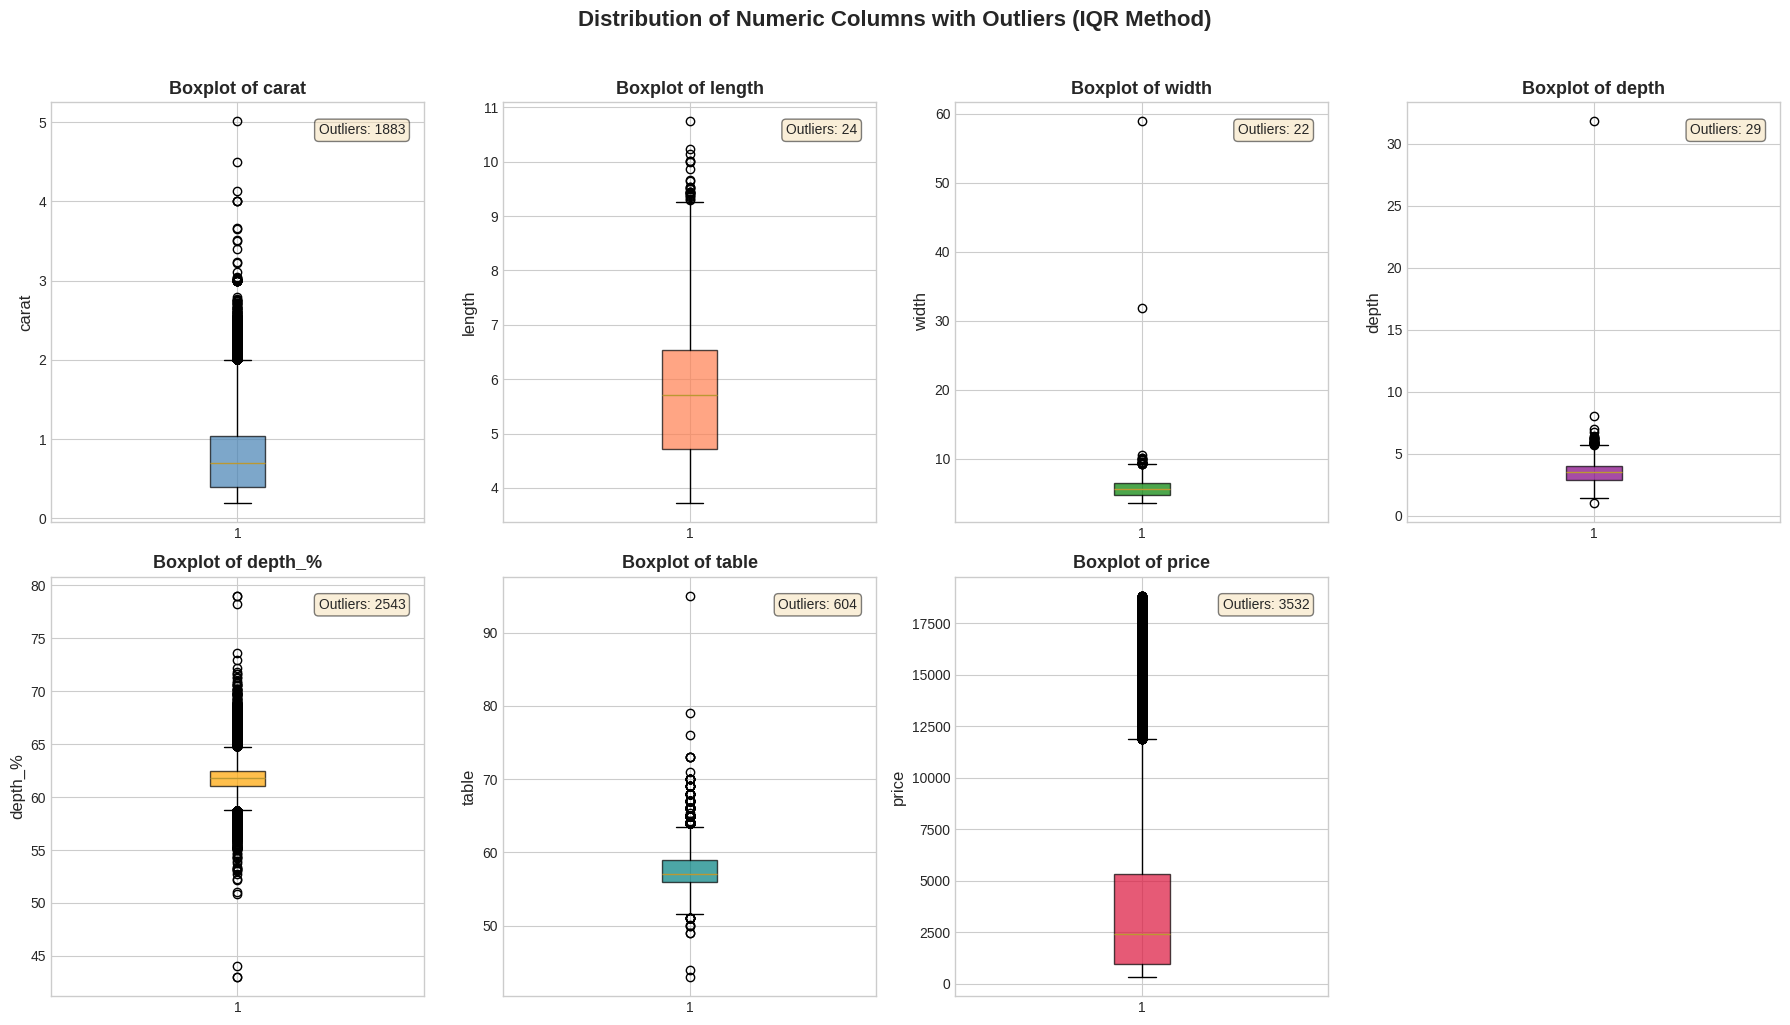

In [11]:
# Visualize distribution of outlier columns using box plots
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

outlier_cols = ['carat', 'length', 'width', 'depth', 'depth_%', 'table', 'price']
colors = ['steelblue', 'coral', 'green', 'purple', 'orange', 'teal', 'crimson']

for i, (col, color) in enumerate(zip(outlier_cols, colors)):
    bp = axes[i].boxplot(df_clean[col], vert=True, patch_artist=True)
    bp['boxes'][0].set_facecolor(color)
    bp['boxes'][0].set_alpha(0.7)
    axes[i].set_ylabel(col, fontsize=12)
    axes[i].set_title(f'Boxplot of {col}', fontsize=13, fontweight='bold')
    
    # Annotate with stats
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    outlier_count = len(df_clean[(df_clean[col] < Q1 - 1.5*IQR) | (df_clean[col] > Q3 + 1.5*IQR)])
    axes[i].text(0.95, 0.95, f'Outliers: {outlier_count}', transform=axes[i].transAxes, 
                 fontsize=10, verticalalignment='top', horizontalalignment='right',
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Hide unused subplot
axes[-1].axis('off')

plt.suptitle('Distribution of Numeric Columns with Outliers (IQR Method)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [12]:
# given that carat, length, width and depth have high correlation with price - we remove the most exteme outliers from these columns to improve model performance
df_clean_outliers_removed = df_clean[
    (df_clean['carat'] <= 4) &
    # (df_clean['length'] <= 10) &
    (df_clean['width'] <= 15) &
    (df_clean['depth'] <= 10) &
    (df_clean['depth'] <= 10) &
    (df_clean['depth_%'] <= 75) &
    (df_clean['depth_%'] >= 45) &
    (df_clean['table'] <= 80) &
    (df_clean['table'] >= 40) 
    
    
].copy()
print(f"Dataset shape after removing extreme outliers: {df_clean_outliers_removed.shape}")

Dataset shape after removing extreme outliers: (53905, 10)


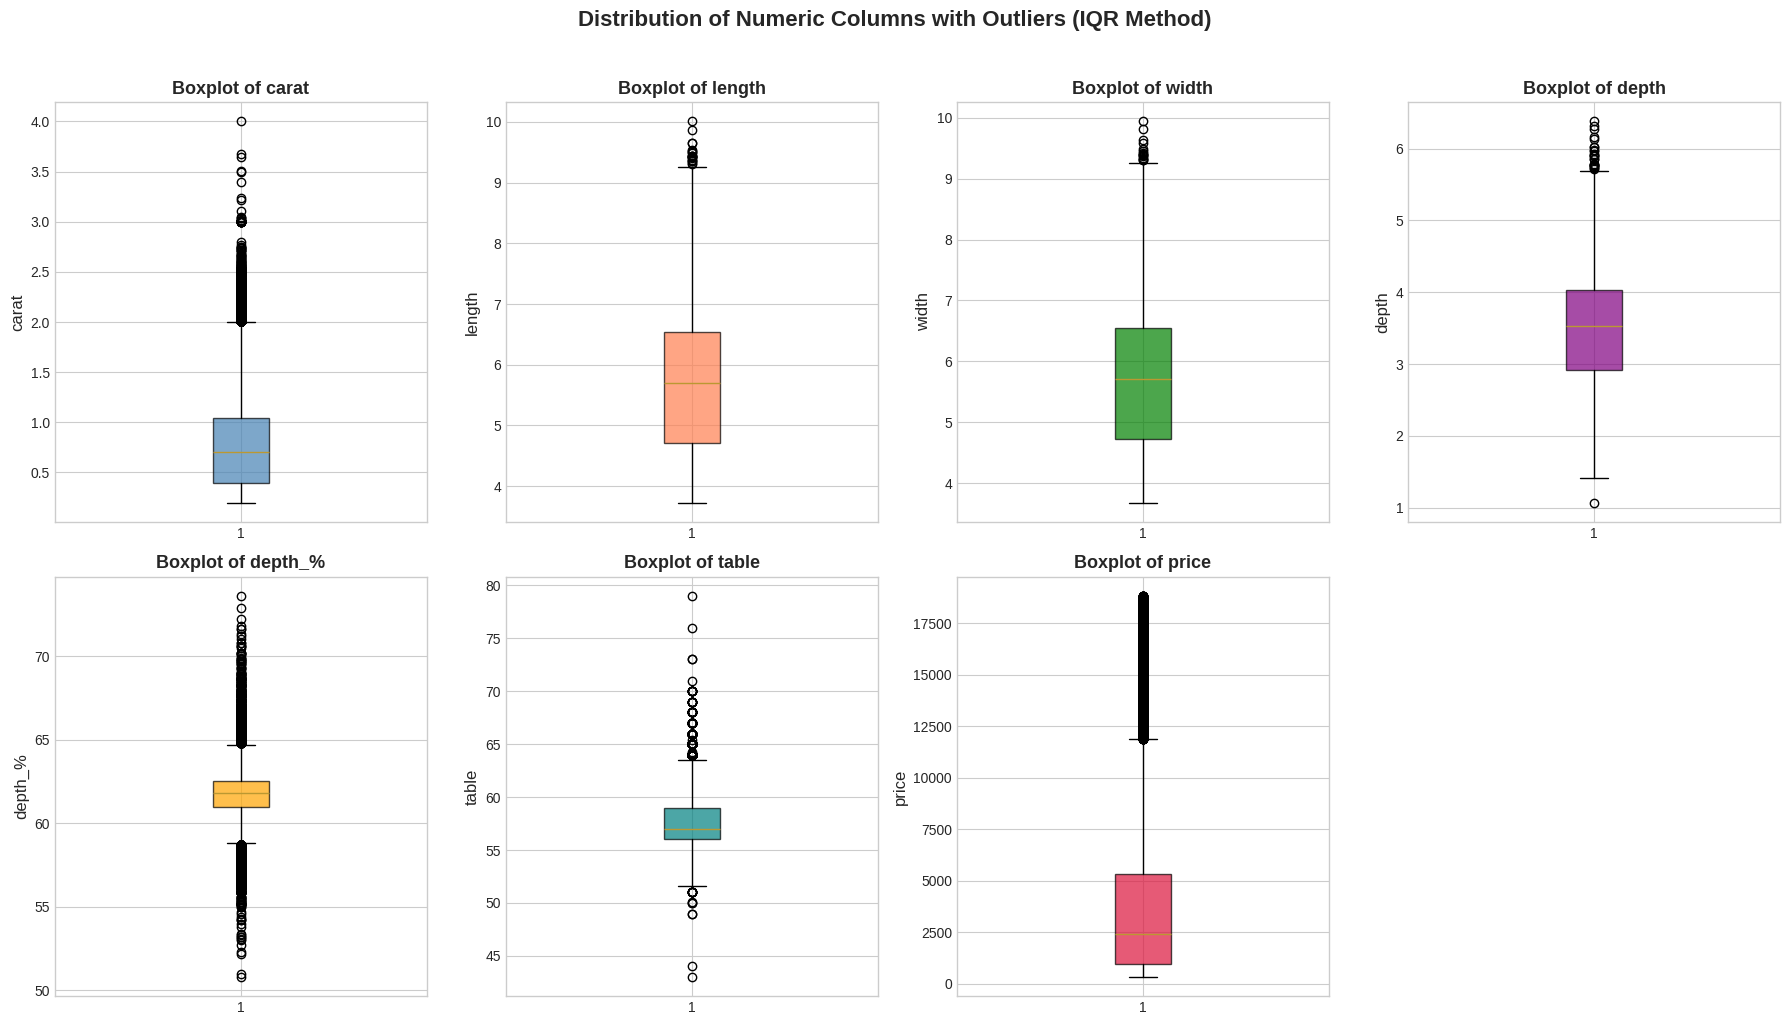

In [13]:
# Visualize distribution of outlier columns using box plots
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

outlier_cols = ['carat', 'length', 'width', 'depth', 'depth_%', 'table', 'price']
colors = ['steelblue', 'coral', 'green', 'purple', 'orange', 'teal', 'crimson']

for i, (col, color) in enumerate(zip(outlier_cols, colors)):
    bp = axes[i].boxplot(df_clean_outliers_removed[col], vert=True, patch_artist=True)
    bp['boxes'][0].set_facecolor(color)
    bp['boxes'][0].set_alpha(0.7)
    axes[i].set_ylabel(col, fontsize=12)
    axes[i].set_title(f'Boxplot of {col}', fontsize=13, fontweight='bold')

axes[-1].axis('off')

plt.suptitle('Distribution of Numeric Columns with Outliers (IQR Method)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [14]:
df_clean = df_clean_outliers_removed.copy()

### 3.2 Encode Categorical Variables

In [15]:
# Define ordinal encodings for categorical variables
# Higher numbers = better quality

cut_categories = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']  # 0-4
color_categories = ['J', 'I', 'H', 'G', 'F', 'E', 'D']  # 0-6 (J=worst, D=best)
clarity_categories = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']  # 0-7

# Create OrdinalEncoder
ordinal_encoder = OrdinalEncoder(categories=[cut_categories, color_categories, clarity_categories])

# Fit and transform categorical columns
df_clean[['cut_encoded', 'color_encoded', 'clarity_encoded']] = ordinal_encoder.fit_transform(
    df_clean[['cut', 'color', 'clarity']]
)

print("Categorical variables encoded:")
print("   Cut Encoding: Fair=0, Good=1, Very Good=2, Premium=3, Ideal=4")
print("   Color Encoding: J=0, I=1, H=2, G=3, F=4, E=5, D=6")
print("   Clarity Encoding: I1=0, SI2=1, SI1=2, VS2=3, VS1=4, VVS2=5, VVS1=6, IF=7")

df_clean[['cut', 'cut_encoded', 'color', 'color_encoded', 'clarity', 'clarity_encoded']].head(10)

Categorical variables encoded:
   Cut Encoding: Fair=0, Good=1, Very Good=2, Premium=3, Ideal=4
   Color Encoding: J=0, I=1, H=2, G=3, F=4, E=5, D=6
   Clarity Encoding: I1=0, SI2=1, SI1=2, VS2=3, VS1=4, VVS2=5, VVS1=6, IF=7


,cut,cut_encoded,color,color_encoded,clarity,clarity_encoded
0,Ideal,4.0,E,5.0,SI2,1.0
1,Premium,3.0,E,5.0,SI1,2.0
2,Good,1.0,E,5.0,VS1,4.0
3,Premium,3.0,I,1.0,VS2,3.0
4,Good,1.0,J,0.0,SI2,1.0
5,Very Good,2.0,J,0.0,VVS2,5.0
6,Very Good,2.0,I,1.0,VVS1,6.0
7,Very Good,2.0,H,2.0,SI1,2.0
8,Fair,0.0,E,5.0,VS2,3.0
9,Very Good,2.0,H,2.0,VS1,4.0


### 3.3 Feature Engineering & Data Splitting

In [16]:
# Define features and target 
feature_columns = ['carat', 'depth_%', 'table', 'length', 'width', 'depth', 
                   'cut_encoded', 'color_encoded', 'clarity_encoded']

X = df_clean[feature_columns]
y = df_clean['price']

# Split data into training and testing sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
# Feature scaling for regularized models
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled[:5]

array([[-0.03917134,  0.03905051,  0.69818989,  0.17504631,  0.1296839 ,
         0.158404  ,  0.08306789,  1.52576809, -0.63974874],
       [-0.50377211,  0.32140189, -0.2035421 , -0.39608103, -0.43663675,
        -0.37634728,  0.98041754, -0.23909998, -0.03272714],
       [ 0.44654764,  0.88610465, -1.55614007,  0.54984863,  0.60611237,
         0.69315528, -0.81428176, -2.00396804, -0.63974874],
       [-1.05284574,  0.03905051, -0.65440809, -1.27061977, -1.26364468,
        -1.25796427,  0.98041754,  0.34918938,  2.39535926],
       [-1.05284574,  0.10963836, -0.2035421 , -1.27954364, -1.27263389,
        -1.25796427,  0.98041754,  0.34918938,  1.78833766]])

---
## 4. Model Training

### 4.1 Linear Regression

In [18]:
# Train Linear Regression Model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predictions
y_pred_lr = lr_model.predict(X_test)

# Extract coefficients
print("=" * 60)
print("LINEAR REGRESSION MODEL")
print("=" * 60)
print(f"  Intercept: {lr_model.intercept_:.2f}")
print(f"  Coefficients:")
for feature, coef in zip(feature_columns, lr_model.coef_):
    print(f"   {feature:20s}: {coef:>12.4f}")

# Display equation
print(f"  Model Equation:")
equation = f"Price = {lr_model.intercept_:.2f}"
for feature, coef in zip(feature_columns, lr_model.coef_):
    sign = "+" if coef >= 0 else "-"
    equation += f" {sign} {abs(coef):.2f} X {feature}"
print(equation)

LINEAR REGRESSION MODEL
  Intercept: -3470.71
  Coefficients:
   carat               :   11328.1142
   depth_%             :      45.1523
   table               :     -20.0664
   length              :   -2057.1223
   width               :    2301.2362
   depth               :   -2155.9203
   cut_encoded         :     126.7263
   color_encoded       :     322.5636
   clarity_encoded     :     488.3876
  Model Equation:
Price = -3470.71 + 11328.11 X carat + 45.15 X depth_% - 20.07 X table - 2057.12 X length + 2301.24 X width - 2155.92 X depth + 126.73 X cut_encoded + 322.56 X color_encoded + 488.39 X clarity_encoded


### 4.2 Polynomial Regression (Degree 2)

In [19]:
# Scale features BEFORE polynomial transformation to prevent numerical instability
# Create a scaler for polynomial features
poly_scaler = StandardScaler()
X_train_scaled_for_poly = poly_scaler.fit_transform(X_train)
X_test_scaled_for_poly = poly_scaler.transform(X_test)

# Create Polynomial Features (degree 2) on SCALED data
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_scaled_for_poly)
X_test_poly = poly.transform(X_test_scaled_for_poly)

# Train Linear Regression on polynomial features
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

# Predictions
y_pred_poly = poly_model.predict(X_test_poly)

print(f"  Intercept: {poly_model.intercept_:.2f}")
print(f"  Top 10 Polynomial Coefficients (by absolute value):")
poly_feature_names = poly.get_feature_names_out(feature_columns)
coef_df = pd.DataFrame({
    'Feature': poly_feature_names,
    'Coefficient': poly_model.coef_
})
# coef_df['Abs_Coef'] = coef_df['Coefficient'].abs()
# top_coefs = coef_df.nlargest(10, 'Abs_Coef')[['Feature', 'Coefficient']]
# print(top_coefs.to_string(index=False))
coef_df.head(10)

  Intercept: 3703.78
  Top 10 Polynomial Coefficients (by absolute value):


,Feature,Coefficient
0,carat,4132.896384
1,depth_%,-111.982345
2,table,-36.621955
3,length,-1311.215329
4,width,319.542048
5,depth,908.716252
6,cut_encoded,91.435021
7,color_encoded,571.222503
8,clarity_encoded,902.024581
9,carat^2,-2487.223884


In [20]:
# Polynomial Regression (Degree 3)
# Scale features BEFORE polynomial transformation to prevent numerical instability
poly3_scaler = StandardScaler()
X_train_scaled_for_poly3 = poly3_scaler.fit_transform(X_train)
X_test_scaled_for_poly3 = poly3_scaler.transform(X_test)

# Create Polynomial Features (degree 3) on SCALED data
poly3 = PolynomialFeatures(degree=3, include_bias=False)
X_train_poly3 = poly3.fit_transform(X_train_scaled_for_poly3)
X_test_poly3 = poly3.transform(X_test_scaled_for_poly3)

# Train Linear Regression on polynomial features (degree 3)
poly3_model = LinearRegression()
poly3_model.fit(X_train_poly3, y_train)

# Predictions
y_pred_poly3 = poly3_model.predict(X_test_poly3)

print(f"  Intercept: {poly3_model.intercept_:.2f}")
print(f"  Top 10 Polynomial Coefficients (deg=3) (by absolute value):")
poly3_feature_names = poly3.get_feature_names_out(feature_columns)
poly3_coef_df = pd.DataFrame({
    'Feature': poly3_feature_names,
    'Coefficient': poly3_model.coef_
})
poly3_coef_df.head(10)

  Intercept: 3479.85
  Top 10 Polynomial Coefficients (deg=3) (by absolute value):


,Feature,Coefficient
0,carat,3795.178835
1,depth_%,316.245508
2,table,59.480765
3,length,-1050.077084
4,width,4107.115602
5,depth,-2679.674006
6,cut_encoded,26.886813
7,color_encoded,522.996568
8,clarity_encoded,722.238498
9,carat^2,1029.125813


### 4.3 Ridge Regression (L2 Regularization)

In [21]:
# Train Ridge Regression Model (uses scaled features)
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_ridge = ridge_model.predict(X_test_scaled)

print("=" * 60)
print("  RIDGE REGRESSION MODEL (L2 Regularization)")
print("=" * 60)
print(f"  Alpha (regularization strength): 1.0")
print(f"  Intercept: {ridge_model.intercept_:,.2f}")
print(f"  Coefficients (scaled features):")
for feature, coef in zip(feature_columns, ridge_model.coef_):
    print(f"   {feature:20s}: {coef:>12,.4f}")

  RIDGE REGRESSION MODEL (L2 Regularization)
  Alpha (regularization strength): 1.0
  Intercept: 3,940.39
  Coefficients (scaled features):
   carat               :   5,360.0303
   depth_%             :      61.6626
   table               :     -44.9881
   length              :  -2,263.9506
   width               :   2,505.1531
   depth               :  -1,473.8608
   cut_encoded         :     140.9047
   color_encoded       :     548.2195
   clarity_encoded     :     804.8539


### 4.4 Lasso Regression (L1 Regularization)

In [22]:
# Train Lasso Regression Model (uses scaled features)
lasso_model = Lasso(alpha=1.0, max_iter=10000)
lasso_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_lasso = lasso_model.predict(X_test_scaled)

print("=" * 60)
print("  LASSO REGRESSION MODEL (L1 Regularization)")
print("=" * 60)
print(f"  Alpha (regularization strength): 1.0")
print(f"  Intercept: {lasso_model.intercept_:,.2f}")
print(f"  Coefficients (scaled features):")
for feature, coef in zip(feature_columns, lasso_model.coef_):
    status = "  (zeroed)" if coef == 0 else ""
    print(f"   {feature:20s}: {coef:>12,.4f} {status}")

# Count non-zero coefficients
n_nonzero = np.sum(lasso_model.coef_ != 0)
print(f"  Lasso selected {n_nonzero}/{len(feature_columns)} features (non-zero coefficients)")

  LASSO REGRESSION MODEL (L1 Regularization)
  Alpha (regularization strength): 1.0
  Intercept: 3,940.39
  Coefficients (scaled features):
   carat               :   5,317.5892 
   depth_%             :       0.0000   (zeroed)
   table               :     -53.7241 
   length              :  -1,652.4788 
   width               :   1,476.1868 
   depth               :  -1,011.0152 
   cut_encoded         :     134.1108 
   color_encoded       :     546.3224 
   clarity_encoded     :     808.5867 
  Lasso selected 8/9 features (non-zero coefficients)


---
## 5. Model Evaluation

### 5.1 Calculate Metrics for All Models

In [23]:
# Function to calculate metrics
def evaluate_model(y_true, y_pred, model_name):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    return {
        'Model': model_name,
        'R² Score': r2,
        'RMSE ($)': rmse,
        'MAE ($)': mae
    }

# Evaluate all models
results = []
results.append(evaluate_model(y_test, y_pred_lr, 'Linear Regression'))
results.append(evaluate_model(y_test, y_pred_poly, 'Polynomial (deg=2)'))
results.append(evaluate_model(y_test, y_pred_poly3, 'Polynomial (deg=3)'))
results.append(evaluate_model(y_test, y_pred_ridge, 'Ridge Regression'))
results.append(evaluate_model(y_test, y_pred_lasso, 'Lasso Regression'))

# Create comparison table
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('R² Score', ascending=False).reset_index(drop=True)

print("=" * 70)
print("  MODEL COMPARISON - EVALUATION METRICS")
print("=" * 70)
print(f"\n{'Model':<25} {'R² Score':>12} {'RMSE ($)':>15} {'MAE ($)':>15}")
print("-" * 70)
for _, row in results_df.iterrows():
    print(f"{row['Model']:<25} {row['R² Score']:>12.4f} {row['RMSE ($)']:>15,.2f} {row['MAE ($)']:>15,.2f}")
print("-" * 70)

# Highlight best model
best_model = results_df.iloc[0]
print(f"  Best Model: {best_model['Model']}")
print(f"   R² Score: {best_model['R² Score']:.4f}")
print(f"   RMSE: ${best_model['RMSE ($)']:,.2f}")
print(f"   MAE: ${best_model['MAE ($)']:,.2f}")

  MODEL COMPARISON - EVALUATION METRICS

Model                         R² Score        RMSE ($)         MAE ($)
----------------------------------------------------------------------
Polynomial (deg=2)              0.9652          738.09          446.39
Polynomial (deg=3)              0.9476          906.09          344.63
Ridge Regression                0.9067        1,209.25          794.47
Linear Regression               0.9067        1,209.31          794.49
Lasso Regression                0.9067        1,209.65          794.05
----------------------------------------------------------------------
  Best Model: Polynomial (deg=2)
   R² Score: 0.9652
   RMSE: $738.09
   MAE: $446.39


### 5.2 Visualize Model Performance

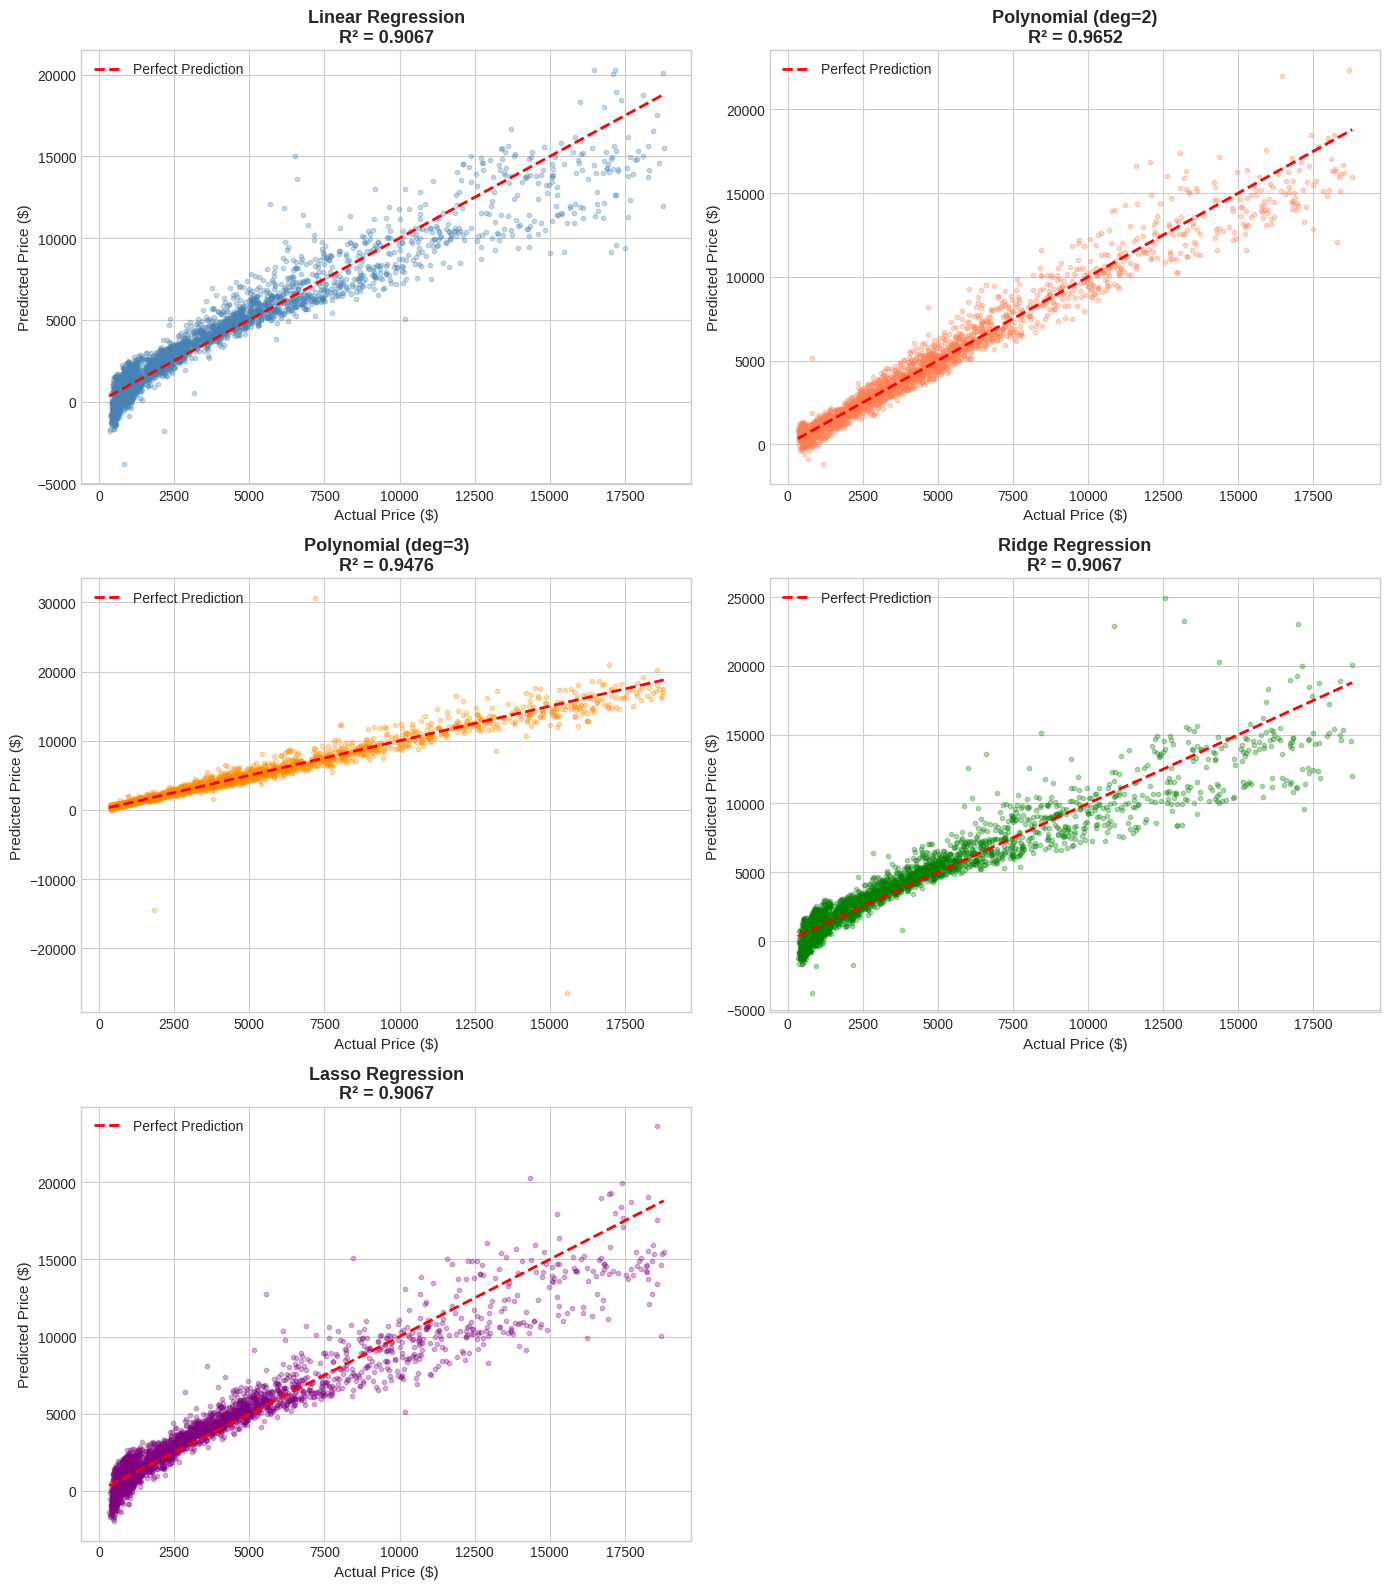

In [24]:
# Actual vs Predicted plots for all models
fig, axes = plt.subplots(3, 2, figsize=(14, 16))

predictions = [
    (y_pred_lr, 'Linear Regression', 'steelblue'),
    (y_pred_poly, 'Polynomial (deg=2)', 'coral'),
    (y_pred_poly3, 'Polynomial (deg=3)', 'darkorange'),
    (y_pred_ridge, 'Ridge Regression', 'green'),
    (y_pred_lasso, 'Lasso Regression', 'purple')
]

for ax, (y_pred, name, color) in zip(axes.flatten(), predictions):
    # Sample 3000 points for clearer visualization
    sample_idx = np.random.choice(len(y_test), size=min(3000, len(y_test)), replace=False)
    y_test_sample = y_test.iloc[sample_idx]
    y_pred_sample = y_pred[sample_idx]
    
    ax.scatter(y_test_sample, y_pred_sample, alpha=0.3, s=10, c=color)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
    ax.set_xlabel('Actual Price ($)', fontsize=11)
    ax.set_ylabel('Predicted Price ($)', fontsize=11)
    ax.set_title(f'{name}\nR² = {r2_score(y_test, y_pred):.4f}', fontsize=13, fontweight='bold')
    ax.legend(loc='upper left')
# Hide any unused subplot
for ax in axes.flatten()[len(predictions):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

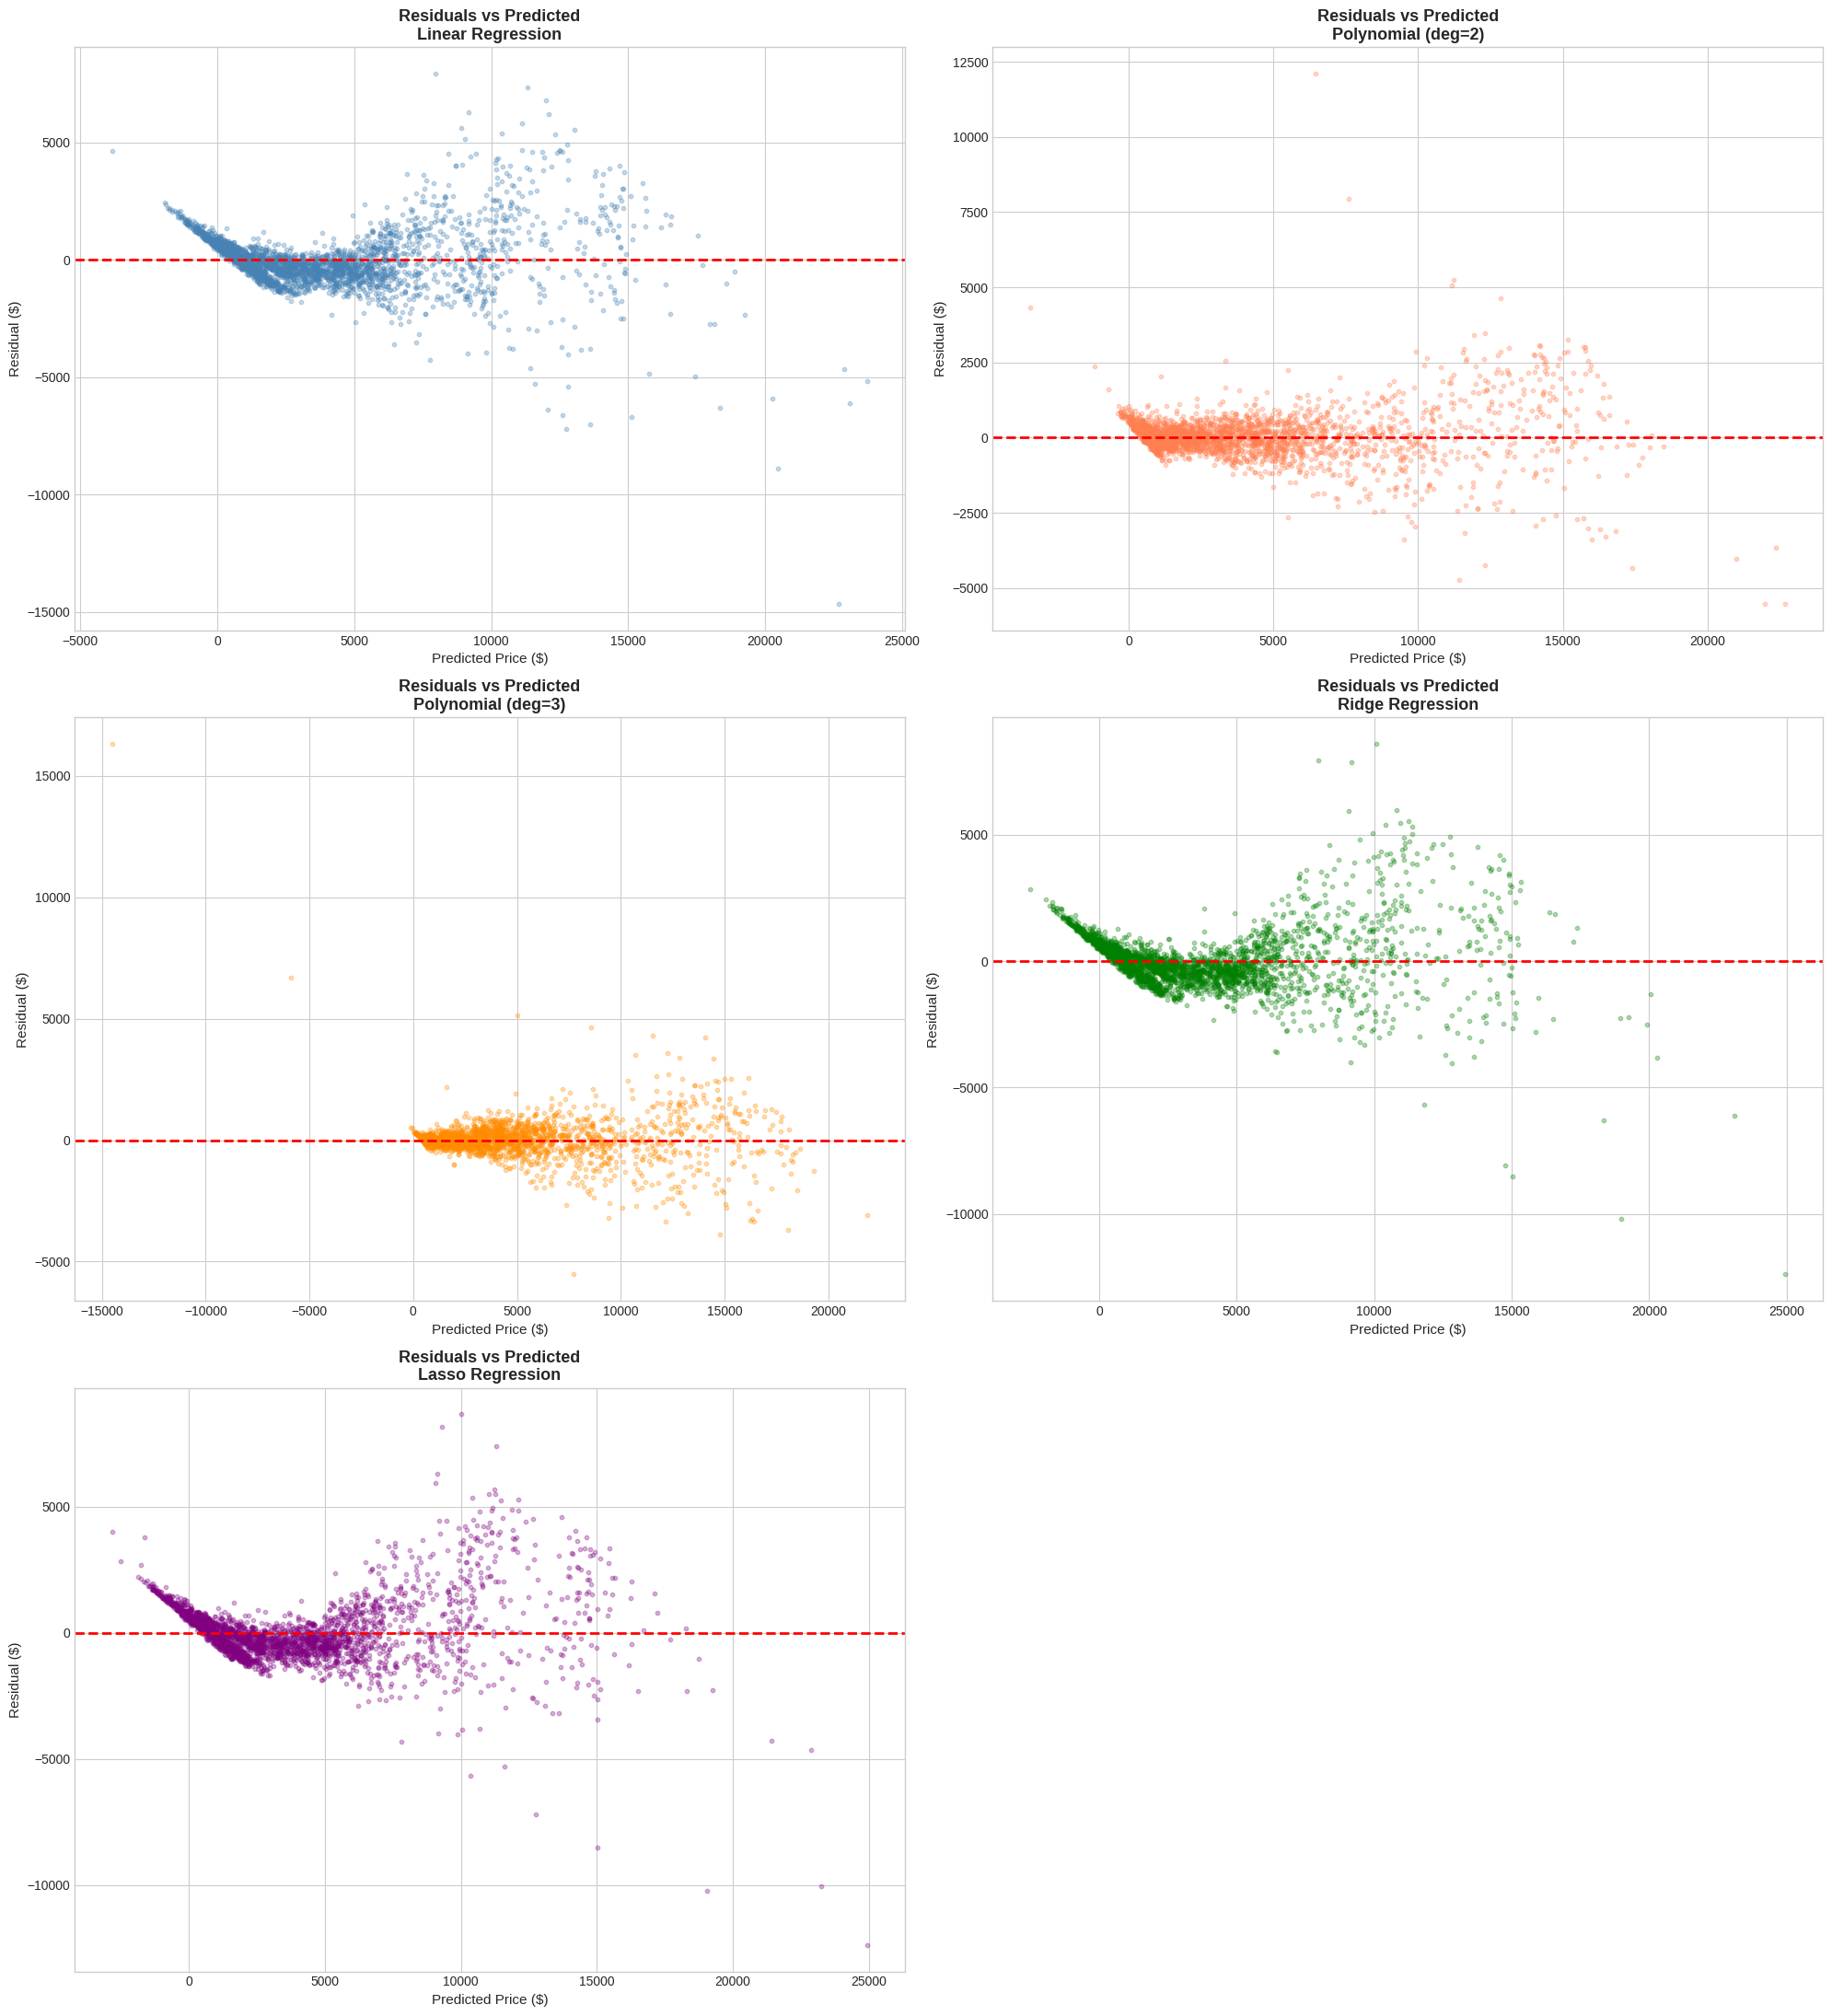

In [25]:
# Residual plots for all models
fig, axes = plt.subplots(3, 2, figsize=(20, 22))

residual_sets = [
    (y_pred_lr, 'Linear Regression', 'steelblue'),
    (y_pred_poly, 'Polynomial (deg=2)', 'coral'),
    (y_pred_poly3, 'Polynomial (deg=3)', 'darkorange'),
    (y_pred_ridge, 'Ridge Regression', 'green'),
    (y_pred_lasso, 'Lasso Regression', 'purple')
]

for ax, (y_pred, name, color) in zip(axes.flatten(), residual_sets):
    residuals = y_test - y_pred
    sample_idx = np.random.choice(len(y_test), size=min(3000, len(y_test)), replace=False)
    ax.scatter(y_pred[sample_idx], residuals.iloc[sample_idx], alpha=0.3, s=10, c=color)
    ax.axhline(0, color='red', linestyle='--', lw=2)
    ax.set_xlabel('Predicted Price ($)', fontsize=11)
    ax.set_ylabel('Residual ($)', fontsize=11)
    ax.set_title(f'Residuals vs Predicted\n{name}', fontsize=13, fontweight='bold')
# Hide any unused subplot
for ax in axes.flatten()[len(residual_sets):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

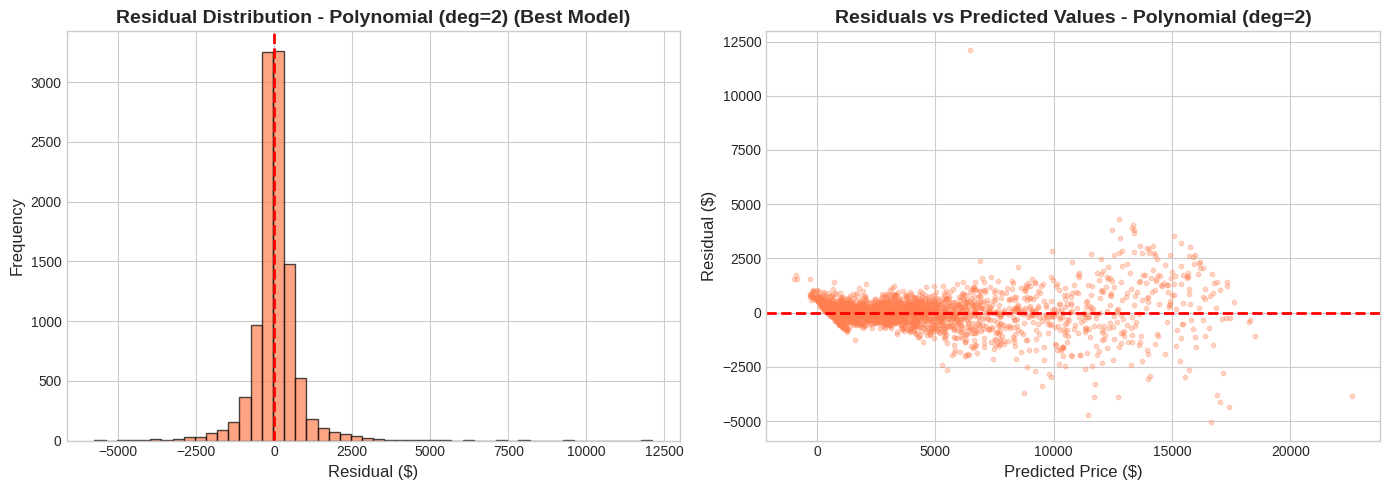

📊 Residual Statistics (Polynomial deg=2 - Best Model):
   Mean: $14.55
   Std Dev: $737.98
   Min: $-5,762.69
   Max: $12,113.10


In [ ]:
# Show residuals for BEST model (Polynomial deg=2)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Calculate residuals for POLYNOMIAL (deg=2) model (actual best performer)
residuals_poly = y_test - y_pred_poly

# Histogram of residuals
axes[0].hist(residuals_poly, bins=50, edgecolor='black', alpha=0.7, color='coral')
axes[0].axvline(0, color='red', linestyle='--', lw=2)
axes[0].set_xlabel('Residual ($)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Residual Distribution - Polynomial (deg=2) (Best Model)', fontsize=14, fontweight='bold')

# Residuals vs Predicted
sample_idx = np.random.choice(len(y_test), size=3000, replace=False)
axes[1].scatter(y_pred_poly[sample_idx], residuals_poly.iloc[sample_idx], alpha=0.3, s=10, c='coral')
axes[1].axhline(0, color='red', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Price ($)', fontsize=12)
axes[1].set_ylabel('Residual ($)', fontsize=12)
axes[1].set_title('Residuals vs Predicted Values - Polynomial (deg=2)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"  Residual Statistics (Polynomial deg=2 - Best Model):")
print(f"   Mean: ${residuals_poly.mean():,.2f}")
print(f"   Std Dev: ${residuals_poly.std():,.2f}")
print(f"   Min: ${residuals_poly.min():,.2f}")
print(f"   Max: ${residuals_poly.max():,.2f}")

### 5.3 Model Comparison Chart

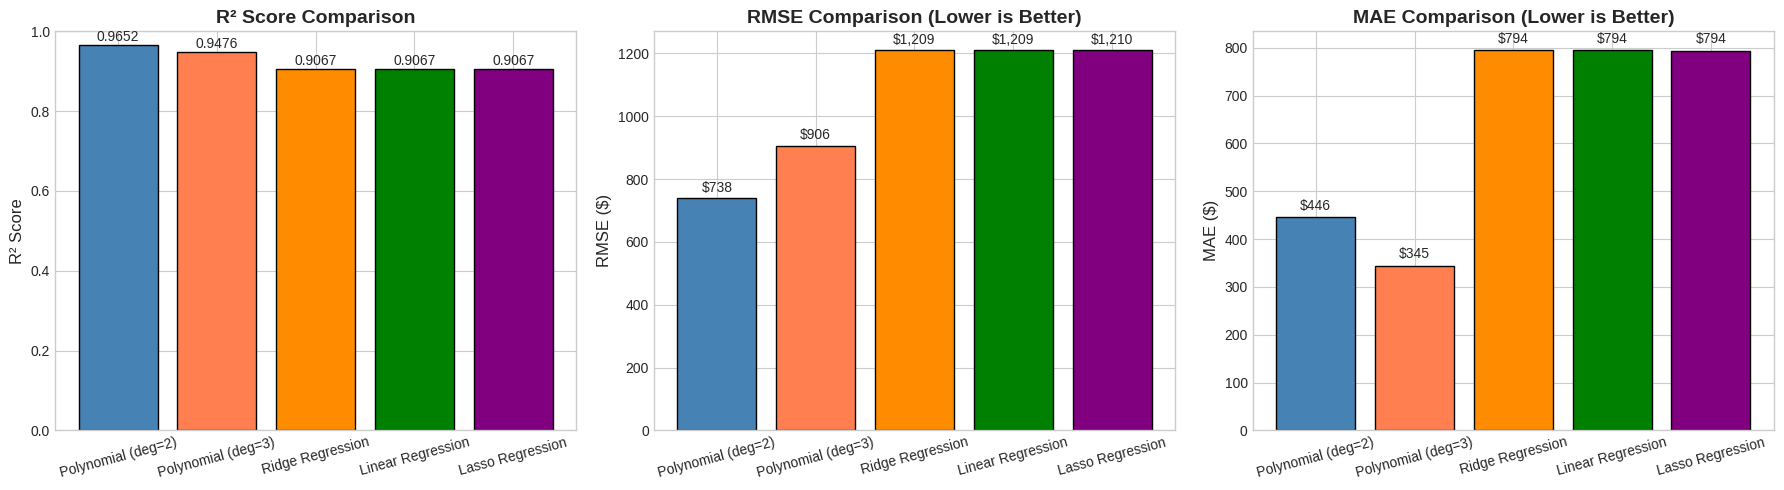

In [27]:
# Bar chart comparison of model metrics
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = results_df['Model'].tolist()
colors = ['steelblue', 'coral', 'darkorange', 'green', 'purple']

# R² Score comparison
bars1 = axes[0].bar(models, results_df['R² Score'], color=colors, edgecolor='black')
axes[0].set_ylabel('R² Score', fontsize=12)
axes[0].set_title('R² Score Comparison', fontsize=14, fontweight='bold')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=15)
for bar, val in zip(bars1, results_df['R² Score']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                 f'{val:.4f}', ha='center', fontsize=10)

# RMSE comparison
bars2 = axes[1].bar(models, results_df['RMSE ($)'], color=colors, edgecolor='black')
axes[1].set_ylabel('RMSE ($)', fontsize=12)
axes[1].set_title('RMSE Comparison (Lower is Better)', fontsize=14, fontweight='bold')
axes[1].tick_params(axis='x', rotation=15)
for bar, val in zip(bars2, results_df['RMSE ($)']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20, 
                 f'${val:,.0f}', ha='center', fontsize=10)

# MAE comparison
bars3 = axes[2].bar(models, results_df['MAE ($)'], color=colors, edgecolor='black')
axes[2].set_ylabel('MAE ($)', fontsize=12)
axes[2].set_title('MAE Comparison (Lower is Better)', fontsize=14, fontweight='bold')
axes[2].tick_params(axis='x', rotation=15)
for bar, val in zip(bars3, results_df['MAE ($)']):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15, 
                 f'${val:,.0f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

---
## 6. Final Model Presentation

### 6.1 Best Model Summary & Equation

In [28]:
# FINAL MODEL PRESENTATION
print("=" * 80)
print("  FINAL MODEL: POLYNOMIAL REGRESSION (deg=2) (Best Performer)")
print("=" * 80)
print("""
Polynomial Regression (degree 2) achieved the highest accuracy with R² ≈ 0.96.
It captures non-linear relationships between features and price better than linear models.
""")

# Polynomial Regression Summary
print("=" * 80)
print("  POLYNOMIAL REGRESSION (deg=2) SUMMARY")
print("=" * 80)
print(f"\nIntercept: {poly_model.intercept_:,.4f}")
print(f"Total polynomial features: {len(poly_model.coef_)}")
print("\nTop 10 Most Influential Features (by absolute coefficient value):")
print("-" * 60)
poly_coef_df = pd.DataFrame({
    'Feature': poly_feature_names,
    'Coefficient': poly_model.coef_
})
poly_coef_df['Abs_Coef'] = poly_coef_df['Coefficient'].abs()
top_features = poly_coef_df.nlargest(10, 'Abs_Coef')[['Feature', 'Coefficient']]
print(top_features.to_string(index=False))
print("-" * 50)

print("\n  Note: Polynomial features include interactions and squared terms")
print("   (e.g., carat^2, carat × clarity_encoded, etc.)")

# Performance metrics
print(f"\n  Performance Metrics:")
print(f"   R² Score: {r2_score(y_test, y_pred_poly):.4f}")
print(f"   RMSE: ${np.sqrt(mean_squared_error(y_test, y_pred_poly)):,.2f}")
print(f"   MAE: ${mean_absolute_error(y_test, y_pred_poly):,.2f}")

  FINAL MODEL: POLYNOMIAL REGRESSION (deg=2) (Best Performer)

Polynomial Regression (degree 2) achieved the highest accuracy with R² ≈ 0.96.
It captures non-linear relationships between features and price better than linear models.

  POLYNOMIAL REGRESSION (deg=2) SUMMARY

Intercept: 3,703.7763
Total polynomial features: 54

Top 10 Most Influential Features (by absolute coefficient value):
------------------------------------------------------------
     Feature  Coefficient
 carat width  5479.862973
       carat  4132.896384
 width depth -3299.767573
 carat depth  2741.710462
carat length -2639.515981
     carat^2 -2487.223884
     width^2  1493.412663
    length^2  1480.229926
      length -1311.215329
length width -1300.183978
--------------------------------------------------

  Note: Polynomial features include interactions and squared terms
   (e.g., carat^2, carat × clarity_encoded, etc.)

  Performance Metrics:
   R² Score: 0.9652
   RMSE: $738.09
   MAE: $446.39


In [29]:
# Polynomial Regression - Top coefficients (simplified presentation)
print("=" * 80)
print("  POLYNOMIAL REGRESSION (DEGREE 2) - TOP FEATURES")
print("=" * 80)
print(f"\nIntercept: {poly_model.intercept_:,.4f}")
print(f"\nTotal polynomial features: {len(poly_model.coef_)}")
print("\nTop 15 Most Influential Features (by absolute coefficient value):")
print("-" * 60)

poly_coef_df = pd.DataFrame({
    'Feature': poly_feature_names,
    'Coefficient': poly_model.coef_
})
poly_coef_df['Abs_Coef'] = poly_coef_df['Coefficient'].abs()
top_features = poly_coef_df.nlargest(15, 'Abs_Coef')[['Feature', 'Coefficient']]
print(top_features.to_string(index=False))

print(f"\n  Performance Metrics:")
print(f"   R² Score: {r2_score(y_test, y_pred_poly):.4f}")
print(f"   RMSE: ${np.sqrt(mean_squared_error(y_test, y_pred_poly)):,.2f}")
print(f"   MAE: ${mean_absolute_error(y_test, y_pred_poly):,.2f}")

  POLYNOMIAL REGRESSION (DEGREE 2) - TOP FEATURES

Intercept: 3,703.7763

Total polynomial features: 54

Top 15 Most Influential Features (by absolute coefficient value):
------------------------------------------------------------
              Feature  Coefficient
          carat width  5479.862973
                carat  4132.896384
          width depth -3299.767573
          carat depth  2741.710462
         carat length -2639.515981
              carat^2 -2487.223884
              width^2  1493.412663
             length^2  1480.229926
               length -1311.215329
         length width -1300.183978
carat clarity_encoded  1153.558882
        depth_% depth -1059.599469
  width color_encoded   963.479837
    depth cut_encoded   930.388737
                depth   908.716252

  Performance Metrics:
   R² Score: 0.9652
   RMSE: $738.09
   MAE: $446.39


### 6.2 Summary Table & Conclusions

In [30]:
# Final Summary Table
print("=" * 80)
print("  FINAL MODEL COMPARISON SUMMARY")
print("=" * 80)

summary_df = results_df.copy()
summary_df['R² Score'] = summary_df['R² Score'].apply(lambda x: f"{x:.4f}")
summary_df['RMSE ($)'] = summary_df['RMSE ($)'].apply(lambda x: f"${x:,.2f}")
summary_df['MAE ($)'] = summary_df['MAE ($)'].apply(lambda x: f"${x:,.2f}")

print("\n")
print(summary_df.to_string(index=False))

# Dynamic conclusions based on actual model performance
print("\n" + "=" * 80)
print("  KEY FINDINGS & CONCLUSIONS")
print("=" * 80)
print(f"""
1. FEATURE IMPORTANCE:
   - Carat is the most influential feature for diamond pricing (correlation: 0.92)
   - Dimensions (length, width, depth) are highly correlated with carat
   - Quality factors (cut, color, clarity) add predictive value

2. MODEL PERFORMANCE:
   - Linear Regression:    R² = {r2_score(y_test, y_pred_lr):.4f}
   - Polynomial (deg=2):   R² = {r2_score(y_test, y_pred_poly):.4f}
   - Polynomial (deg=3):   R² = {r2_score(y_test, y_pred_poly3):.4f}
   - Ridge Regression:     R² = {r2_score(y_test, y_pred_ridge):.4f}
   - Lasso Regression:     R² = {r2_score(y_test, y_pred_lasso):.4f}

3. BEST MODEL SELECTION:
   🏆 {results_df.iloc[0]['Model']} is recommended because:
   - Highest R² = {results_df.iloc[0]['R² Score']:.4f}
   - Good balance of accuracy and interpretability
   - Robust and computationally efficient

4. RECOMMENDATIONS:
   - For production: Use Linear Regression for interpretability
   - For higher accuracy: Consider ensemble methods (Random Forest, XGBoost)
   - Future improvement: Try log(price) transformation for the skewed target

5. LIMITATIONS:
   - Price distribution is right-skewed (log transformation may help)
   - Ordinal encoding assumes equal spacing between categories
   - High multicollinearity between carat and dimensions
""")

print("=" * 80)
print("  ANALYSIS COMPLETE")
print("=" * 80)

  FINAL MODEL COMPARISON SUMMARY


             Model R² Score  RMSE ($) MAE ($)
Polynomial (deg=2)   0.9652   $738.09 $446.39
Polynomial (deg=3)   0.9476   $906.09 $344.63
  Ridge Regression   0.9067 $1,209.25 $794.47
 Linear Regression   0.9067 $1,209.31 $794.49
  Lasso Regression   0.9067 $1,209.65 $794.05

  KEY FINDINGS & CONCLUSIONS

1. FEATURE IMPORTANCE:
   - Carat is the most influential feature for diamond pricing (correlation: 0.92)
   - Dimensions (length, width, depth) are highly correlated with carat
   - Quality factors (cut, color, clarity) add predictive value

2. MODEL PERFORMANCE:
   - Linear Regression:    R² = 0.9067
   - Polynomial (deg=2):   R² = 0.9652
   - Polynomial (deg=3):   R² = 0.9476
   - Ridge Regression:     R² = 0.9067
   - Lasso Regression:     R² = 0.9067

3. BEST MODEL SELECTION:
   🏆 Polynomial (deg=2) is recommended because:
   - Highest R² = 0.9652
   - Good balance of accuracy and interpretability
   - Robust and computationally efficient

4. RE